In [1]:
import datetime
import itertools
import glob
from concurrent.futures import ProcessPoolExecutor, as_completed

import cartopy.crs as ccrs
import dask.dataframe as dd
import gcsfs
import matplotlib.dates as dates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from tqdm.auto import tqdm

from pycontrails.utils import temp

# Contrails.org forecasts

In [2]:
with temp.temp_file() as tmp:
    gcsfs.GCSFileSystem().get(f"gs://contrails-301217-public-tmp/contrails-org-forecasts/1725166800_350.nc", tmp)
    ds = xr.open_dataset(tmp)

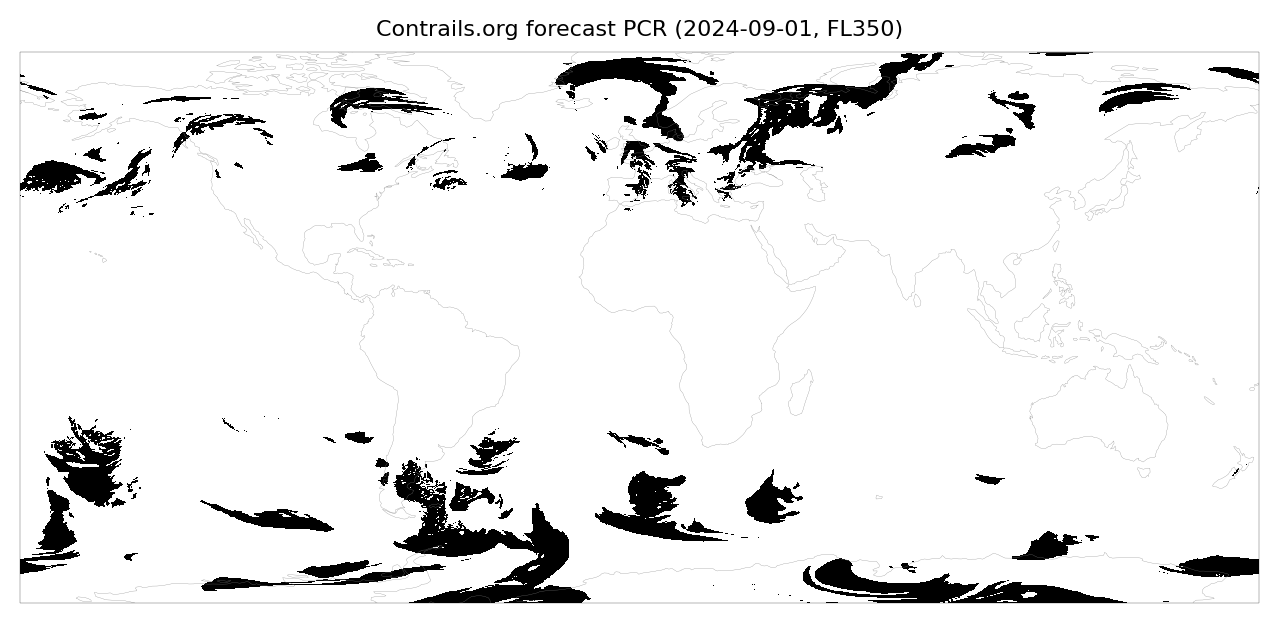

In [3]:
plt.figure(figsize=(6.5, 3), dpi=200, constrained_layout=True)
ax = plt.subplot(111, projection=ccrs.PlateCarree())
ax.pcolormesh(ds["longitude"], ds["latitude"], ds["pcr"].squeeze().T, cmap="Greys", shading="nearest")
ax.coastlines(color="gray", lw=0.1)
plt.setp(ax.spines.values(), linewidth=0.1)
ax.set_title("Contrails.org forecast PCR (2024-09-01, FL350)", fontsize=8)
ax.set_extent([-180, 180, -80, 80]);

# Google forecasts

In [4]:
with temp.temp_file() as tmp:
    gcsfs.GCSFileSystem().get(f"gs://contrails-301217-public-tmp/google-forecast/1725166800_350.nc", tmp)
    ds = xr.open_dataset(tmp)

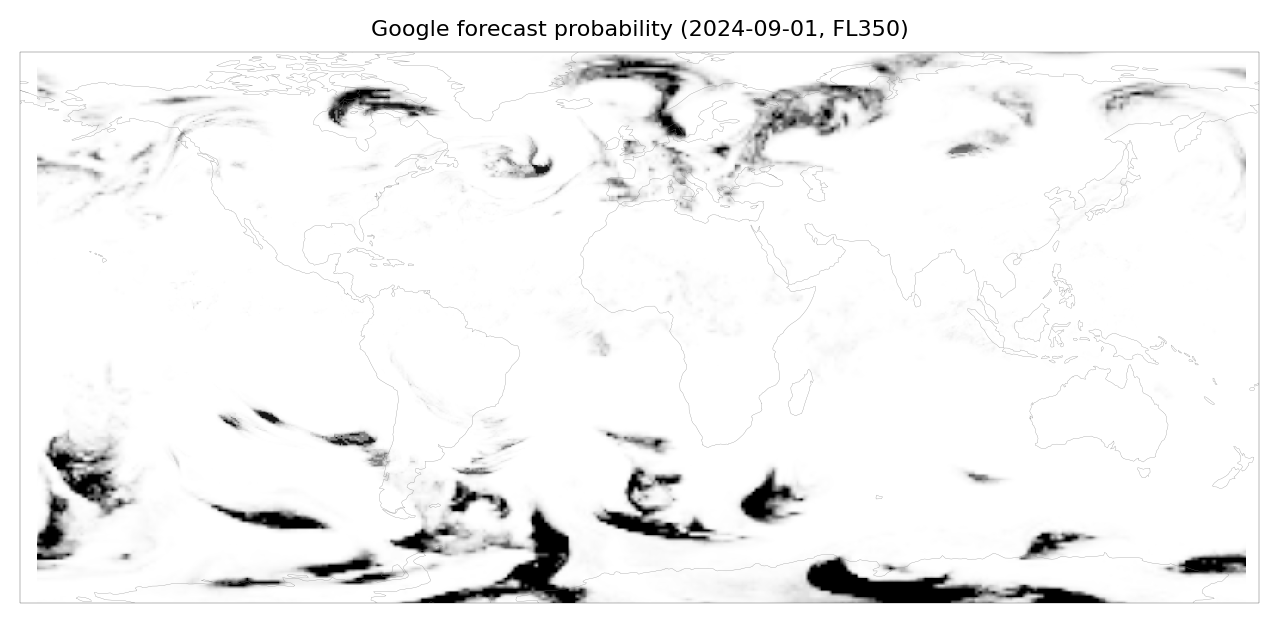

In [5]:
plt.figure(figsize=(6.5, 3), dpi=200, constrained_layout=True)
ax = plt.subplot(111, projection=ccrs.PlateCarree())
ax.pcolormesh(ds["longitude"], ds["latitude"], ds["ppcr"].squeeze().T, cmap="Greys", shading="nearest")
ax.coastlines(color="gray", lw=0.1)
plt.setp(ax.spines.values(), linewidth=0.1)
ax.set_title("Google forecast probability (2024-09-01, FL350)", fontsize=8)
ax.set_extent([-180, 180, -80, 80]);

# Download processed datasets

In [6]:
! gcloud --no-user-output-enabled storage cp -r gs://contrails-301217-contrail-bench/2025Q1/contrails-org-adsb data/
! gcloud --no-user-output-enabled storage cp -r gs://contrails-301217-contrail-bench/2025Q1/contrails-org-iagos data/
! gcloud --no-user-output-enabled storage cp -r gs://contrails-301217-contrail-bench/2025Q1/contrails-org-gruan data/
! gcloud --no-user-output-enabled storage cp -r gs://contrails-301217-contrail-bench/2025Q1/contrails-org-contrailwatch data/

In [7]:
! gcloud --no-user-output-enabled storage cp -r gs://contrails-301217-contrail-bench/2025Q1/google-adsb data/
! gcloud --no-user-output-enabled storage cp -r gs://contrails-301217-contrail-bench/2025Q1/google-iagos data/
! gcloud --no-user-output-enabled storage cp -r gs://contrails-301217-contrail-bench/2025Q1/google-gruan data/
! gcloud --no-user-output-enabled storage cp -r gs://contrails-301217-contrail-bench/2025Q1/google-contrailwatch data/

In [8]:
! gcloud --no-user-output-enabled storage cp -r gs://contrails-301217-contrail-bench/2025Q1/contrails-org-iagos-flight-distance data/
! gcloud --no-user-output-enabled storage cp -r gs://contrails-301217-contrail-bench/2025Q1/contrails-org-gruan-flight-distance data/
! gcloud --no-user-output-enabled storage cp -r gs://contrails-301217-contrail-bench/2025Q1/contrails-org-contrailwatch-flight-distance data/

In [9]:
! gcloud --no-user-output-enabled storage cp -r gs://contrails-301217-contrail-bench/2025Q1/google-iagos-flight-distance data/
! gcloud --no-user-output-enabled storage cp -r gs://contrails-301217-contrail-bench/2025Q1/google-gruan-flight-distance data/
! gcloud --no-user-output-enabled storage cp -r gs://contrails-301217-contrail-bench/2025Q1/google-contrailwatch-flight-distance data/

# Helper functions, colors, etc

In [10]:
def open_dfs(path):
    """Open and concatenate all dataframes in directory."""
    df_list = [pd.read_parquet(f) for f in tqdm(sorted(glob.glob(f"data/{path}/*.pq")), desc=path)]
    return pd.concat(df_list, axis="index")

In [11]:
def penalty(df, grouping_key):
    """Compute flight distance penalty."""
    return df.groupby(grouping_key)[["adsb_dist_in_forecast_pcr", "adsb_dist"]].apply(
        lambda x: x["adsb_dist_in_forecast_pcr"].sum() / x["adsb_dist"].sum()
    )

In [12]:
def hit_rate(df, grouping_key):
    """Compute hit rate."""
    return df.groupby(grouping_key)[["observed_pcr_area_in_forecast_pcr", "observed_pcr_area"]].apply(
        lambda x: x["observed_pcr_area_in_forecast_pcr"].sum() / x["observed_pcr_area"].sum()
    )

In [13]:
def hit_rate_flight_distance(df, grouping_key):
    """Compute hit rate."""
    return df.groupby(grouping_key)[["flight_distance_in_observed_and_forecast_pcr", "flight_distance_in_observed_pcr"]].apply(
        lambda x: x["flight_distance_in_observed_and_forecast_pcr"].sum() / x["flight_distance_in_observed_pcr"].sum()
    )

In [14]:
exo_black = "#161a26"
tropo_blue = "#1093ff"
solar_orange = "#f26400"
gray50 = "#939598"

In [15]:
fs = gcsfs.GCSFileSystem()
with fs.open("gs://contrails-301217-contrail-bench/tmp/2025Q1/iagos/pcr_flight_m_count.txt") as f:
    pcr_flight_m = float(f.read())
with fs.open("gs://contrails-301217-contrail-bench/tmp/2025Q1/iagos/total_flight_m_count.txt") as f:
    total_flight_m = float(f.read())
iagos_pcr_rate = pcr_flight_m / total_flight_m

# Contrails.org forecast

In [16]:
df_adsb = open_dfs("contrails-org-adsb")
df_iagos = open_dfs("contrails-org-iagos")
df_gruan = open_dfs("contrails-org-gruan")
df_contrailwatch = open_dfs("contrails-org-contrailwatch")

contrails-org-adsb:   0%|          | 0/8784 [00:00<?, ?it/s]

contrails-org-iagos:   0%|          | 0/8784 [00:00<?, ?it/s]

contrails-org-gruan:   0%|          | 0/8784 [00:00<?, ?it/s]

contrails-org-contrailwatch:   0%|          | 0/5880 [00:00<?, ?it/s]

In [17]:
df = pd.DataFrame({
    "penalty": penalty(df_adsb, "horizontal_buffer"),
    "iagos_hit_rate": hit_rate(df_iagos, "horizontal_buffer"),
    "gruan_hit_rate": hit_rate(df_gruan, "horizontal_buffer"),
    "contrailwatch_hit_rate": hit_rate(df_contrailwatch, "horizontal_buffer"),
})

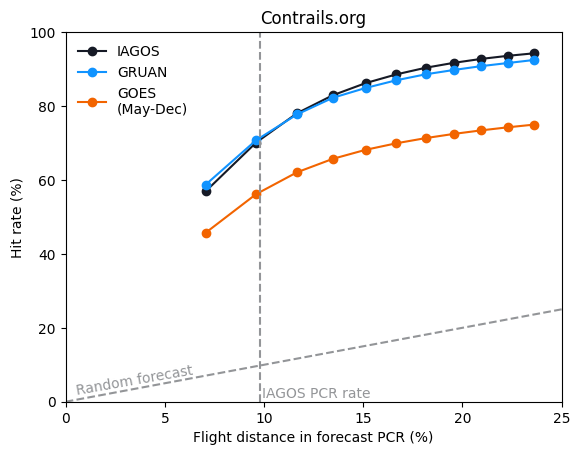

In [18]:
plt.plot(100 * df["penalty"], 100 * df["iagos_hit_rate"], "-o", color=exo_black, label="IAGOS")
plt.plot(100 * df["penalty"], 100 * df["gruan_hit_rate"], "-o", color=tropo_blue, label="GRUAN")
plt.plot(100 * df["penalty"], 100 * df["contrailwatch_hit_rate"], "-o", color=solar_orange, label="GOES\n(May-Dec)")
plt.xlabel("Flight distance in forecast PCR (%)")
plt.ylabel("Hit rate (%)")
plt.xlim([0, 25])
plt.ylim([0, 100])
plt.gca().axline([0, 0], [100, 100], ls="--", color=gray50)
plt.gca().axvline(x=100 * iagos_pcr_rate, ls="--", color=gray50)
plt.annotate("Random forecast", xy=(0.02, 0.02), xycoords="axes fraction", color=gray50, rotation=10)
plt.annotate("IAGOS PCR rate", xy=(100 * iagos_pcr_rate + 0.1, 1), color=gray50)
plt.legend(loc="upper left", frameon=False)
plt.title("Contrails.org")

plt.savefig("contrails-org.pdf", bbox_inches="tight")
plt.savefig("contrails-org.png", dpi=300, bbox_inches="tight");

# Contrails.org forecasts (December only)

In [19]:
df_contrails_adsb = df_adsb[df_adsb["time"].between("2024-12-01 00:00", "2024-12-31 23:00")]
df_contrails_iagos = df_iagos[df_iagos["time"].between("2024-12-01 00:00", "2024-12-31 23:00")]
df_contrails_gruan = df_gruan[df_gruan["time"].between("2024-12-01 00:00", "2024-12-31 23:00")]
df_contrails_contrailwatch = df_contrailwatch[df_contrailwatch["time"].between("2024-12-01 00:00", "2024-12-31 23:00")]

In [20]:
df = pd.DataFrame({
    "penalty": penalty(df_contrails_adsb, "horizontal_buffer"),
    "iagos_hit_rate": hit_rate(df_contrails_iagos, "horizontal_buffer"),
    "gruan_hit_rate": hit_rate(df_contrails_gruan, "horizontal_buffer"),
    "contrailwatch_hit_rate": hit_rate(df_contrails_contrailwatch, "horizontal_buffer"),
})

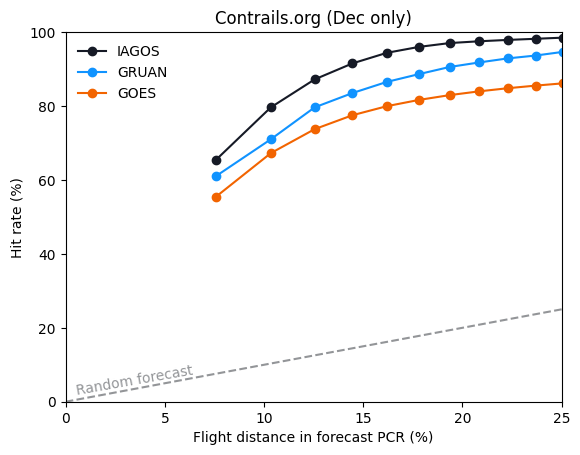

In [21]:
plt.plot(100 * df["penalty"], 100 * df["iagos_hit_rate"], "-o", color=exo_black, label="IAGOS")
plt.plot(100 * df["penalty"], 100 * df["gruan_hit_rate"], "-o", color=tropo_blue, label="GRUAN")
plt.plot(100 * df["penalty"], 100 * df["contrailwatch_hit_rate"], "-o", color=solar_orange, label="GOES")
plt.xlabel("Flight distance in forecast PCR (%)")
plt.ylabel("Hit rate (%)")
plt.xlim([0, 25])
plt.ylim([0, 100])
plt.gca().axline([0, 0], [100, 100], ls="--", color=gray50)
# plt.gca().axvline(x=100 * iagos_pcr_rate, ls="--", color=gray50)
plt.annotate("Random forecast", xy=(0.02, 0.02), xycoords="axes fraction", color=gray50, rotation=10)
# plt.annotate("IAGOS PCR rate", xy=(100 * iagos_pcr_rate + 0.1, 1), color=gray50)
plt.legend(loc="upper left", frameon=False)
plt.title("Contrails.org (Dec only)");

# Contrails.org + Google forecasts (September only)

In [22]:
df_contrails_adsb = df_adsb[df_adsb["time"].between("2024-09-01 00:00", "2024-12-31 23:00")]
df_contrails_iagos = df_iagos[df_iagos["time"].between("2024-09-01 00:00", "2024-12-31 23:00")]
df_contrails_gruan = df_gruan[df_gruan["time"].between("2024-09-01 00:00", "2024-12-31 23:00")]
df_contrails_contrailwatch = df_contrailwatch[df_contrailwatch["time"].between("2024-09-01 00:00", "2024-12-31 23:00")]

In [23]:
df_contrails_org = pd.DataFrame({
    "penalty": penalty(df_contrails_adsb, "horizontal_buffer"),
    "iagos_hit_rate": hit_rate(df_contrails_iagos, "horizontal_buffer"),
    "gruan_hit_rate": hit_rate(df_contrails_gruan, "horizontal_buffer"),
    "contrailwatch_hit_rate": hit_rate(df_contrails_contrailwatch, "horizontal_buffer"),
})

In [24]:
df_google_adsb = open_dfs("google-adsb")
df_google_iagos = open_dfs("google-iagos")
df_google_gruan = open_dfs("google-gruan")
df_google_contrailwatch = open_dfs("google-contrailwatch")

google-adsb:   0%|          | 0/2928 [00:00<?, ?it/s]

google-iagos:   0%|          | 0/2928 [00:00<?, ?it/s]

google-gruan:   0%|          | 0/2928 [00:00<?, ?it/s]

google-contrailwatch:   0%|          | 0/2928 [00:00<?, ?it/s]

In [25]:
df_google = pd.DataFrame({
    "penalty": penalty(df_google_adsb, "probability_threshold"),
    "iagos_hit_rate": hit_rate(df_google_iagos, "probability_threshold"),
    "gruan_hit_rate": hit_rate(df_google_gruan, "probability_threshold"),
    "contrailwatch_hit_rate": hit_rate(df_google_contrailwatch, "probability_threshold"),
})

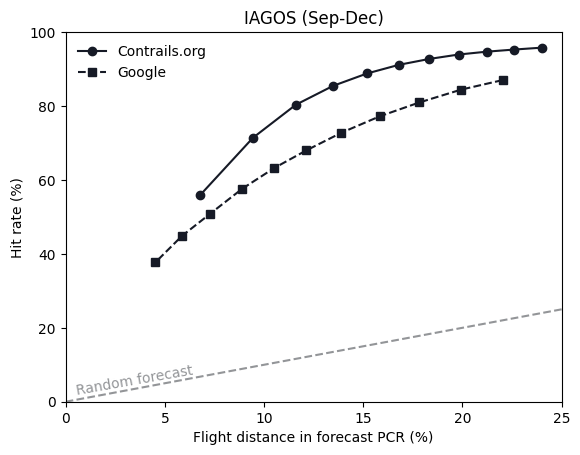

In [26]:
plt.plot(100 * df_contrails_org["penalty"], 100 * df_contrails_org["iagos_hit_rate"], "-o", color=exo_black, label="Contrails.org")
plt.plot(100 * df_google["penalty"], 100 * df_google["iagos_hit_rate"], "--s", color=exo_black, label="Google")
plt.xlabel("Flight distance in forecast PCR (%)")
plt.ylabel("Hit rate (%)")
plt.xlim([0, 25])
plt.ylim([0, 100])
plt.gca().axline([0, 0], [100, 100], ls="--", color=gray50)
# plt.gca().axvline(x=100 * iagos_pcr_rate, ls="--", color=gray50)
plt.annotate("Random forecast", xy=(0.02, 0.02), xycoords="axes fraction", color=gray50, rotation=10)
# plt.annotate("IAGOS PCR rate", xy=(100 * iagos_pcr_rate + 0.1, 1), color=gray50)
plt.legend(loc="upper left", frameon=False)
plt.title("IAGOS (Sep-Dec)");

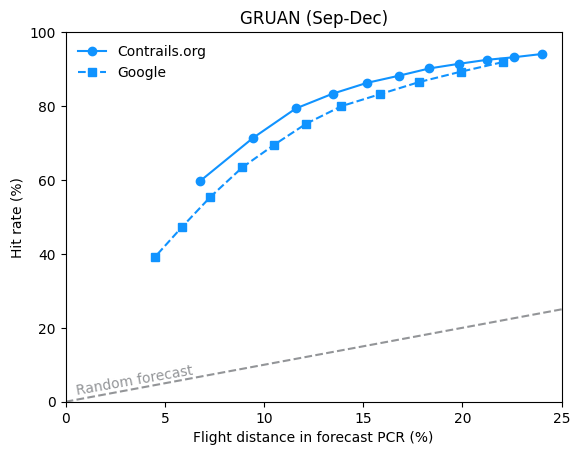

In [27]:
plt.plot(100 * df_contrails_org["penalty"], 100 * df_contrails_org["gruan_hit_rate"], "-o", color=tropo_blue, label="Contrails.org")
plt.plot(100 * df_google["penalty"], 100 * df_google["gruan_hit_rate"], "--s", color=tropo_blue, label="Google")
plt.xlabel("Flight distance in forecast PCR (%)")
plt.ylabel("Hit rate (%)")
plt.xlim([0, 25])
plt.ylim([0, 100])
plt.gca().axline([0, 0], [100, 100], ls="--", color=gray50)
# plt.gca().axvline(x=100 * iagos_pcr_rate, ls="--", color=gray50)
plt.annotate("Random forecast", xy=(0.02, 0.02), xycoords="axes fraction", color=gray50, rotation=10)
# plt.annotate("IAGOS PCR rate", xy=(100 * iagos_pcr_rate + 0.1, 1), color=gray50)
plt.legend(loc="upper left", frameon=False)
plt.title("GRUAN (Sep-Dec)");

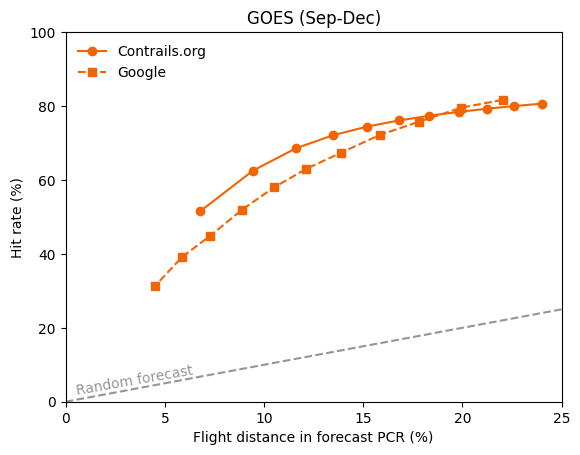

In [28]:
plt.plot(100 * df_contrails_org["penalty"], 100 * df_contrails_org["contrailwatch_hit_rate"], "-o", color=solar_orange, label="Contrails.org")
plt.plot(100 * df_google["penalty"], 100 * df_google["contrailwatch_hit_rate"], "--s", color=solar_orange, label="Google")
plt.xlabel("Flight distance in forecast PCR (%)")
plt.ylabel("Hit rate (%)")
plt.xlim([0, 25])
plt.ylim([0, 100])
plt.gca().axline([0, 0], [100, 100], ls="--", color=gray50)
# plt.gca().axvline(x=100 * iagos_pcr_rate, ls="--", color=gray50)
plt.annotate("Random forecast", xy=(0.02, 0.02), xycoords="axes fraction", color=gray50, rotation=10)
# plt.annotate("IAGOS PCR rate", xy=(100 * iagos_pcr_rate + 0.1, 1), color=gray50)
plt.legend(loc="upper left", frameon=False)
plt.title("GOES (Sep-Dec)");

# Contrails.org forecast (hit rate based on flight distance)

In [29]:
df_adsb = open_dfs("contrails-org-adsb")
df_iagos = open_dfs("contrails-org-iagos")
df_gruan = open_dfs("contrails-org-gruan")
df_contrailwatch = open_dfs("contrails-org-contrailwatch")
df_iagos_fd = open_dfs("contrails-org-iagos-flight-distance")
df_gruan_fd = open_dfs("contrails-org-gruan-flight-distance")
df_contrailwatch_fd = open_dfs("contrails-org-contrailwatch-flight-distance")

contrails-org-adsb:   0%|          | 0/8784 [00:00<?, ?it/s]

contrails-org-iagos:   0%|          | 0/8784 [00:00<?, ?it/s]

contrails-org-gruan:   0%|          | 0/8784 [00:00<?, ?it/s]

contrails-org-contrailwatch:   0%|          | 0/5880 [00:00<?, ?it/s]

contrails-org-iagos-flight-distance:   0%|          | 0/8784 [00:00<?, ?it/s]

contrails-org-gruan-flight-distance:   0%|          | 0/8784 [00:00<?, ?it/s]

contrails-org-contrailwatch-flight-distance:   0%|          | 0/5880 [00:00<?, ?it/s]

In [30]:
df = pd.DataFrame({
    "penalty": penalty(df_adsb, "horizontal_buffer"),
    "iagos_hit_rate": hit_rate(df_iagos, "horizontal_buffer"),
    "iagos_hit_rate_flight_distance": hit_rate_flight_distance(df_iagos_fd, "horizontal_buffer"),
    "gruan_hit_rate": hit_rate(df_gruan, "horizontal_buffer"),
    "gruan_hit_rate_flight_distance": hit_rate_flight_distance(df_gruan_fd, "horizontal_buffer"),
    "contrailwatch_hit_rate": hit_rate(df_contrailwatch, "horizontal_buffer"),
    "contrailwatch_hit_rate_flight_distance": hit_rate_flight_distance(df_contrailwatch_fd, "horizontal_buffer"),
})

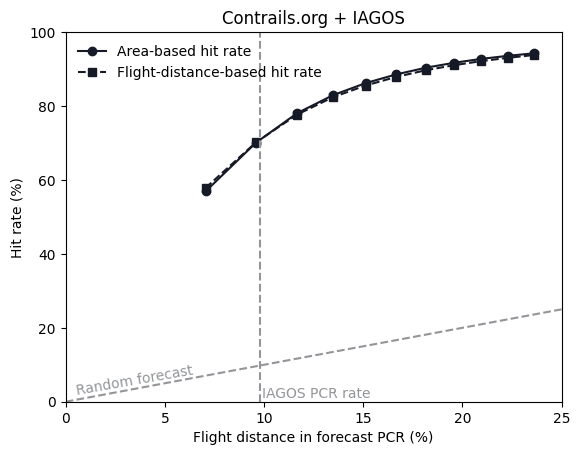

In [31]:
plt.plot(100 * df["penalty"], 100 * df["iagos_hit_rate"], "-o", color=exo_black, label="Area-based hit rate")
plt.plot(100 * df["penalty"], 100 * df["iagos_hit_rate_flight_distance"], "--s", color=exo_black, label="Flight-distance-based hit rate")
plt.xlabel("Flight distance in forecast PCR (%)")
plt.ylabel("Hit rate (%)")
plt.xlim([0, 25])
plt.ylim([0, 100])
plt.gca().axline([0, 0], [100, 100], ls="--", color=gray50)
plt.gca().axvline(x=100 * iagos_pcr_rate, ls="--", color=gray50)
plt.annotate("Random forecast", xy=(0.02, 0.02), xycoords="axes fraction", color=gray50, rotation=10)
plt.annotate("IAGOS PCR rate", xy=(100 * iagos_pcr_rate + 0.1, 1), color=gray50)
plt.legend(loc="upper left", frameon=False)
plt.title("Contrails.org + IAGOS");

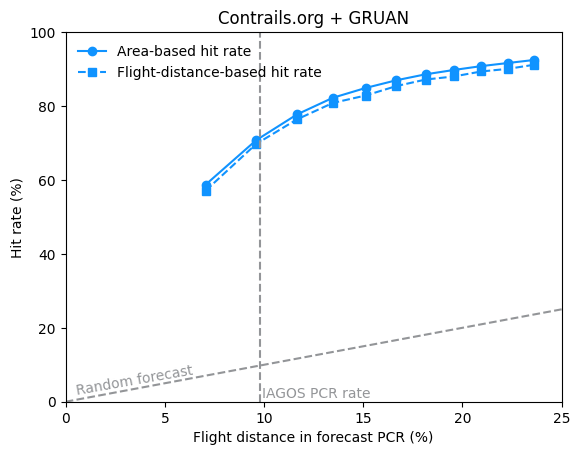

In [32]:
plt.plot(100 * df["penalty"], 100 * df["gruan_hit_rate"], "-o", color=tropo_blue, label="Area-based hit rate")
plt.plot(100 * df["penalty"], 100 * df["gruan_hit_rate_flight_distance"], "--s", color=tropo_blue, label="Flight-distance-based hit rate")
plt.xlabel("Flight distance in forecast PCR (%)")
plt.ylabel("Hit rate (%)")
plt.xlim([0, 25])
plt.ylim([0, 100])
plt.gca().axline([0, 0], [100, 100], ls="--", color=gray50)
plt.gca().axvline(x=100 * iagos_pcr_rate, ls="--", color=gray50)
plt.annotate("Random forecast", xy=(0.02, 0.02), xycoords="axes fraction", color=gray50, rotation=10)
plt.annotate("IAGOS PCR rate", xy=(100 * iagos_pcr_rate + 0.1, 1), color=gray50)
plt.legend(loc="upper left", frameon=False)
plt.title("Contrails.org + GRUAN");

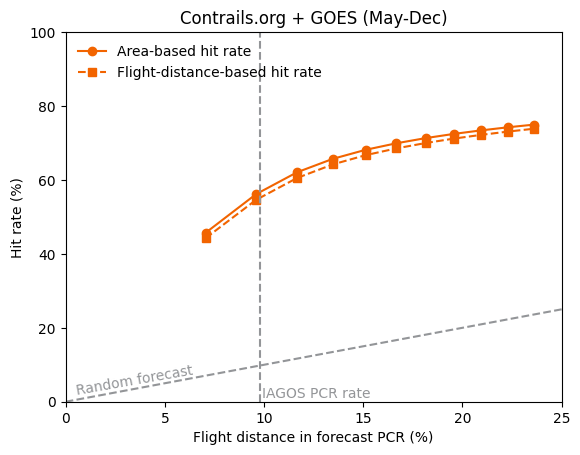

In [33]:
plt.plot(100 * df["penalty"], 100 * df["contrailwatch_hit_rate"], "-o", color=solar_orange, label="Area-based hit rate")
plt.plot(100 * df["penalty"], 100 * df["contrailwatch_hit_rate_flight_distance"], "--s", color=solar_orange, label="Flight-distance-based hit rate")
plt.xlabel("Flight distance in forecast PCR (%)")
plt.ylabel("Hit rate (%)")
plt.xlim([0, 25])
plt.ylim([0, 100])
plt.gca().axline([0, 0], [100, 100], ls="--", color=gray50)
plt.gca().axvline(x=100 * iagos_pcr_rate, ls="--", color=gray50)
plt.annotate("Random forecast", xy=(0.02, 0.02), xycoords="axes fraction", color=gray50, rotation=10)
plt.annotate("IAGOS PCR rate", xy=(100 * iagos_pcr_rate + 0.1, 1), color=gray50)
plt.legend(loc="upper left", frameon=False)
plt.title("Contrails.org + GOES (May-Dec)");

# Google forecast (hit rate based on flight distance)

In [34]:
df_adsb = open_dfs("google-adsb")
df_iagos = open_dfs("google-iagos")
df_gruan = open_dfs("google-gruan")
df_contrailwatch = open_dfs("google-contrailwatch")
df_iagos_fd = open_dfs("google-iagos-flight-distance")
df_gruan_fd = open_dfs("google-gruan-flight-distance")
df_contrailwatch_fd = open_dfs("google-contrailwatch-flight-distance")

google-adsb:   0%|          | 0/2928 [00:00<?, ?it/s]

google-iagos:   0%|          | 0/2928 [00:00<?, ?it/s]

google-gruan:   0%|          | 0/2928 [00:00<?, ?it/s]

google-contrailwatch:   0%|          | 0/2928 [00:00<?, ?it/s]

google-iagos-flight-distance:   0%|          | 0/2928 [00:00<?, ?it/s]

google-gruan-flight-distance:   0%|          | 0/2928 [00:00<?, ?it/s]

google-contrailwatch-flight-distance:   0%|          | 0/2928 [00:00<?, ?it/s]

In [35]:
df = pd.DataFrame({
    "penalty": penalty(df_adsb, "probability_threshold"),
    "iagos_hit_rate": hit_rate(df_iagos, "probability_threshold"),
    "iagos_hit_rate_flight_distance": hit_rate_flight_distance(df_iagos_fd, "probability_threshold"),
    "gruan_hit_rate": hit_rate(df_gruan, "probability_threshold"),
    "gruan_hit_rate_flight_distance": hit_rate_flight_distance(df_gruan_fd, "probability_threshold"),
    "contrailwatch_hit_rate": hit_rate(df_contrailwatch, "probability_threshold"),
    "contrailwatch_hit_rate_flight_distance": hit_rate_flight_distance(df_contrailwatch_fd, "probability_threshold"),
})

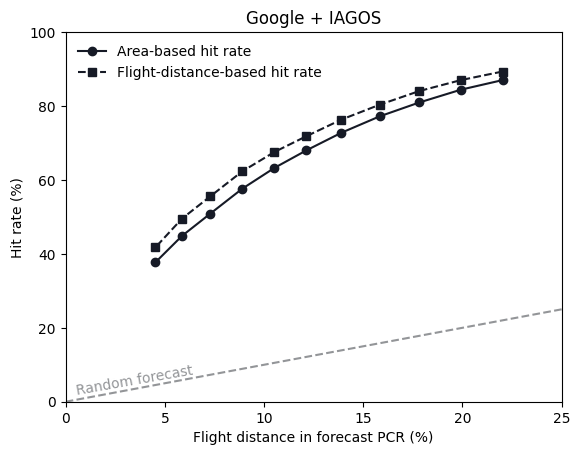

In [36]:
plt.plot(100 * df["penalty"], 100 * df["iagos_hit_rate"], "-o", color=exo_black, label="Area-based hit rate")
plt.plot(100 * df["penalty"], 100 * df["iagos_hit_rate_flight_distance"], "--s", color=exo_black, label="Flight-distance-based hit rate")
plt.xlabel("Flight distance in forecast PCR (%)")
plt.ylabel("Hit rate (%)")
plt.xlim([0, 25])
plt.ylim([0, 100])
plt.gca().axline([0, 0], [100, 100], ls="--", color=gray50)
# plt.gca().axvline(x=100 * iagos_pcr_rate, ls="--", color=gray50)
plt.annotate("Random forecast", xy=(0.02, 0.02), xycoords="axes fraction", color=gray50, rotation=10)
# plt.annotate("IAGOS PCR rate", xy=(100 * iagos_pcr_rate + 0.1, 1), color=gray50)
plt.legend(loc="upper left", frameon=False)
plt.title("Google + IAGOS");

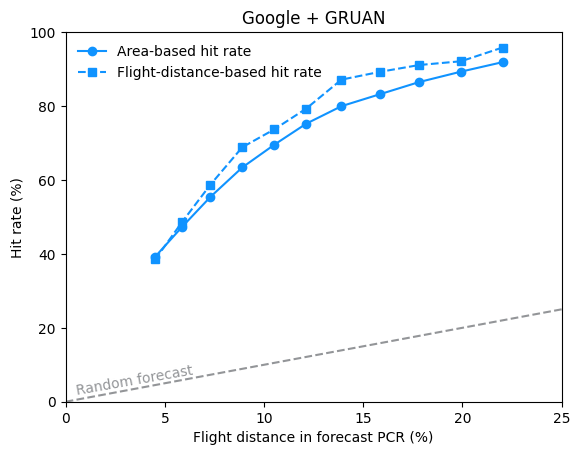

In [37]:
plt.plot(100 * df["penalty"], 100 * df["gruan_hit_rate"], "-o", color=tropo_blue, label="Area-based hit rate")
plt.plot(100 * df["penalty"], 100 * df["gruan_hit_rate_flight_distance"], "--s", color=tropo_blue, label="Flight-distance-based hit rate")
plt.xlabel("Flight distance in forecast PCR (%)")
plt.ylabel("Hit rate (%)")
plt.xlim([0, 25])
plt.ylim([0, 100])
plt.gca().axline([0, 0], [100, 100], ls="--", color=gray50)
# plt.gca().axvline(x=100 * iagos_pcr_rate, ls="--", color=gray50)
plt.annotate("Random forecast", xy=(0.02, 0.02), xycoords="axes fraction", color=gray50, rotation=10)
# plt.annotate("IAGOS PCR rate", xy=(100 * iagos_pcr_rate + 0.1, 1), color=gray50)
plt.legend(loc="upper left", frameon=False)
plt.title("Google + GRUAN");

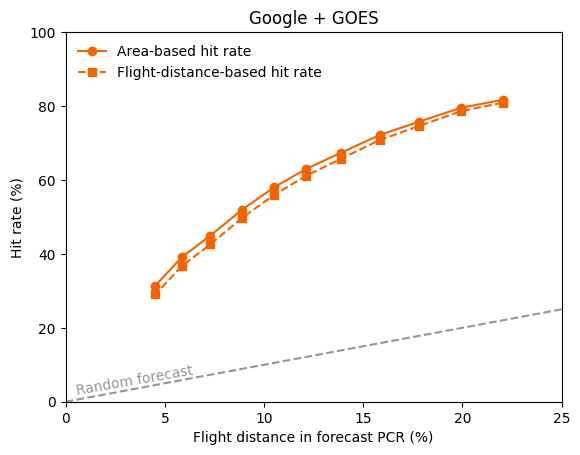

In [38]:
plt.plot(100 * df["penalty"], 100 * df["contrailwatch_hit_rate"], "-o", color=solar_orange, label="Area-based hit rate")
plt.plot(100 * df["penalty"], 100 * df["contrailwatch_hit_rate_flight_distance"], "--s", color=solar_orange, label="Flight-distance-based hit rate")
plt.xlabel("Flight distance in forecast PCR (%)")
plt.ylabel("Hit rate (%)")
plt.xlim([0, 25])
plt.ylim([0, 100])
plt.gca().axline([0, 0], [100, 100], ls="--", color=gray50)
# plt.gca().axvline(x=100 * iagos_pcr_rate, ls="--", color=gray50)
plt.annotate("Random forecast", xy=(0.02, 0.02), xycoords="axes fraction", color=gray50, rotation=10)
# plt.annotate("IAGOS PCR rate", xy=(100 * iagos_pcr_rate + 0.1, 1), color=gray50)
plt.legend(loc="upper left", frameon=False)
plt.title("Google + GOES");

# Relative number of observations

In [39]:
df_iagos = open_dfs("contrails-org-iagos")
df_gruan = open_dfs("contrails-org-gruan")
df_contrailwatch = open_dfs("contrails-org-contrailwatch")

contrails-org-iagos:   0%|          | 0/8784 [00:00<?, ?it/s]

contrails-org-gruan:   0%|          | 0/8784 [00:00<?, ?it/s]

contrails-org-contrailwatch:   0%|          | 0/5880 [00:00<?, ?it/s]

In [40]:
iagos = df_iagos[df_iagos["horizontal_buffer"] == 0]
area_iagos = iagos.groupby(iagos["time"].dt.date)["observed_pcr_area"].mean()

gruan = df_gruan[df_gruan["horizontal_buffer"] == 0]
area_gruan = gruan.groupby(gruan["time"].dt.date)["observed_pcr_area"].mean()

contrailwatch = df_contrailwatch[df_contrailwatch["horizontal_buffer"] == 0]
area_contrailwatch = contrailwatch.groupby(contrailwatch["time"].dt.date)["observed_pcr_area"].mean()

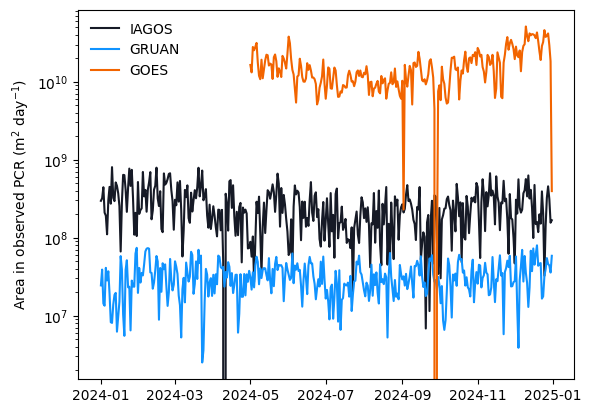

In [41]:
plt.plot(area_iagos.index, area_iagos, "-", color=exo_black, label="IAGOS")
plt.plot(area_gruan.index, area_gruan, "-", color=tropo_blue, label="GRUAN")
plt.plot(area_contrailwatch.index, area_contrailwatch, "-", color=solar_orange, label="GOES")
plt.ylabel("Area in observed PCR (m$^2$ day$^{-1}$)")
plt.gca().set_yscale("log")
plt.legend(loc="upper left", frameon=False);

In [42]:
iagos = df_iagos_fd[df_iagos_fd["horizontal_buffer"] == 0]
dist_iagos = iagos.groupby(iagos["time"].dt.date)["flight_distance_in_observed_pcr"].mean()

gruan = df_gruan_fd[df_gruan_fd["horizontal_buffer"] == 0]
dist_gruan = gruan.groupby(gruan["time"].dt.date)["flight_distance_in_observed_pcr"].mean()

contrailwatch = df_contrailwatch_fd[df_contrailwatch_fd["horizontal_buffer"] == 0]
dist_contrailwatch = contrailwatch.groupby(contrailwatch["time"].dt.date)["flight_distance_in_observed_pcr"].mean()

KeyError: 'horizontal_buffer'

In [ ]:
plt.plot(dist_iagos.index, dist_iagos, "-", color=exo_black, label="IAGOS")
plt.plot(dist_gruan.index, dist_gruan, "-", color=tropo_blue, label="GRUAN")
plt.plot(dist_contrailwatch.index, dist_contrailwatch, "-", color=solar_orange, label="GOES")
plt.ylabel("Flight distance in observed PCR (m day$^{-1}$)")
plt.gca().set_yscale("log")
plt.legend(loc="upper left", frameon=False);